In [1]:
# Transformers example -> Reverseing sequence of numbers


In [1]:
import haiku as hk
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
import optax

from probjax.nn.transformers import Transformer
from probjax.utils.odeint import _odeint

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [2]:
ts = jnp.linspace(0, 3, 100)

def drift_lotka_volterra(t, data, alpha,beta, gamma, delta):
    predator, prey = data
    d_predator = alpha * predator - beta * predator * prey
    d_prey = -gamma * prey + delta * predator * prey
    return d_predator, d_prey



In [3]:
def generate_data(key, n):
    theta1 = jax.nn.sigmoid(jrandom.normal(key, (n,1))*2)*2
    theta2 = jax.nn.sigmoid(jrandom.normal(key, (n,1))*2)*2
    theta3 = jax.nn.sigmoid(jrandom.normal(key, (n,1))*2)*2
    theta4 = jax.nn.sigmoid(jrandom.normal(key, (n,1))*2)*2
    predator, prey = jax.vmap(_odeint, in_axes=(None, None, None, 0,0,0,0))(drift_lotka_volterra, (1., 0.5), ts, theta1, theta2, theta3, theta4)
    predator = predator + jrandom.normal(key, predator.shape) * 0.001
    prey = prey + jrandom.normal(key, prey.shape) * 0.001

    return jnp.concatenate([theta1, theta2, theta3, theta4, predator, prey], axis=1).reshape((n, -1, 1))


data = generate_data(jrandom.PRNGKey(1), 5)

T_max = data.shape[1]

node_ids = jnp.arange(T_max)

In [4]:
key = jrandom.PRNGKey(0)

In [5]:
from probjax.nn.helpers import SinusoidalEmbedding

In [19]:

def model(t, x, node_ids, condition_mask):
    condition_mask = condition_mask.astype(int)
    # Embed
    embedding_net = hk.nets.MLP([1, 100, 100])
    embedding_id_nets = hk.Embed(T_max, 100)
    embedding_condition_nets = hk.Embed(T_max, 100)
    embedding_time = SinusoidalEmbedding(100)
    model = Transformer(num_heads=2, num_layers=4, attn_size=x.shape[-1], dropout_rate=0.0, save_attention_weights=False)


    value_embeddings = embedding_net(x)
    id_embeddings = embedding_id_nets(node_ids)
    id_condition_embeddings = embedding_condition_nets(condition_mask)
    time_embeddings = embedding_time(t.reshape(-1,1,1))


    x_encoded = value_embeddings + id_embeddings + id_condition_embeddings

    # Encode
    h = model(x_encoded, context=time_embeddings)
    out = hk.Linear(1)(h)
    return out


In [20]:
init, model_fn = hk.transform(model)
params = init(key, jnp.ones(data.shape[0]), data, node_ids, jnp.zeros_like(node_ids))

In [18]:
times = jax.random.uniform(key, (data.shape[0], 1, 1), minval=1e-6, maxval=1.0)
out = model_fn(params, key, times, data, node_ids, jnp.ones_like(node_ids))

out.shape

TypeError: state argument does not appear valid. It should be a mapping but is of type <class 'jaxlib.xla_extension.ArrayImpl'>. For reference the parameters for apply are `apply(params, rng, ...)`` for `hk.transform` and `apply(params, state, rng, ...)` for `hk.transform_with_state`.
The argument was: Array([0, 0], dtype=uint32).

In [262]:
optimizer = optax.adam(1e-4)
opt_state = optimizer.init(params)

In [264]:
T = 1.
sigma= 50.

def drift_fn(x, t):
    return 0.

def diffusion_fn(x, t):
    return sigma**t

def marginal_std(x, t):
    return jnp.sqrt(1/(2*jnp.log(sigma)) * (sigma**(2*t) - 1))


def sbd_forward(key, x0, t):
    noise = jax.random.normal(key, x0.shape)
    std = marginal_std(x0, t)
    x_noised = x0 + std * noise
    return x_noised, noise

In [265]:

def loss_fn(params, key, batch_size= 32):

    rng_model, rng_time, rng_sample, rng_data = jax.random.split(key, 4)

    times = jax.random.uniform(rng_time, (batch_size, 1, 1), minval=1e-6, maxval=1.0)
    batch_xs = generate_data(rng_data, batch_size) # n, T_max, 1

    # Forward diffusion
    batch_noisy_xs, batch_noise = sbd_forward(rng_sample, batch_xs, times)
    std = marginal_std(batch_xs, times)
    # Predict noise
    score = model_fn(params, rng_model,times, batch_noisy_xs, node_ids, jnp.zeros_like(node_ids))

    # Loss
    loss = jnp.mean(jnp.sum((score + 1/std * batch_noise) ** 2, -1))
    return loss


@jax.jit
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [273]:
for i in range(1000):
    key = jrandom.PRNGKey(i)
    loss, params, opt_state = update(params, key, opt_state)
    if (i % 100) == 0:
        print(loss)

2.7498674
4.3889503
2.9378932
1.2187219
1.5423151
3.5151682
4.400955
2.4244788


KeyboardInterrupt: 

In [267]:

def sample_fn(params, key, shape, time_steps=500):
    x_T = jax.random.normal(key, shape + (T_max, 1)) * marginal_std(jnp.zeros(shape), 1)
    ts = jnp.linspace(1, 1e-6, time_steps)
    time_steps = ts[0] - ts[1]
    for t in ts:
        time = jnp.ones( (shape[0],1,1), dtype=int) * t
        score = model_fn(params,key+1, time, x_T, node_ids, jnp.zeros_like(node_ids))
        g = diffusion_fn(x_T, t)
        f = drift_fn(x_T, t)
        subkey, key = jax.random.split(key)
        noise = jax.random.normal(subkey, shape + (T_max, 1))
        x_T = x_T - ((f - g**2 * score)*time_steps + g * noise * jnp.sqrt(time_steps))
    return x_T

In [268]:
samples = sample_fn(params, jrandom.PRNGKey(0), (5, ))

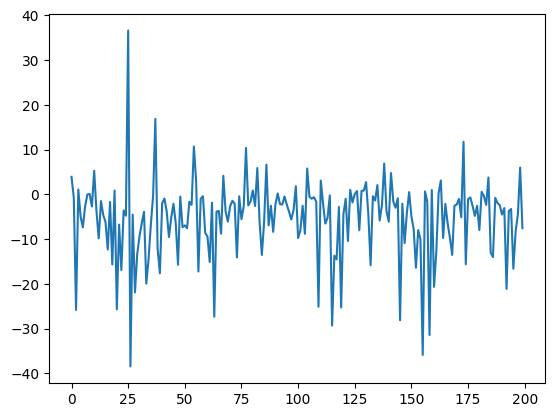

In [272]:
thetas = samples[:, :4, 0]
xs = samples[:, 4:, 0]

plt.plot(xs[2])